# Witching-Hour -- do expirations move the market?
### Triple/quadruple witching on SPY: real volume effect, no tradable return edge

![Signal: Mixed](https://img.shields.io/badge/Signal-Mixed-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Mechanical_effect%3F: Confirmed](https://img.shields.io/badge/Mechanical_effect%3F-Confirmed-8b949e?style=flat-square)

Four times a year, on the third Friday of March, June, September, and December, equity index options, stock options, and futures all expire on the same day. Traders call it *witching* — and the story goes that the huge hedging and unwinding flows *move the market* in a predictable way. Some say volume and volatility spike. Some say the market reliably drops on expiry Friday. Some say you can *trade around it*. This notebook asks: which of those claims actually hold up?

> **This is the plain-language layer.** Want the HAC t-stats, the year-demeaned volume maths, and the cost sweep? That's the companion, **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)** — same story, deeper.
>
> **Not investment advice.** A reproducible research tool: every chart below is drawn by the code beside it. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False,
                     "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from witching_hour import data, strategy as st

TICKER = "SPY"
CACHE_PATH = data._cache_path(TICKER, data.DEFAULT_CACHE)

def _have_cache():
    return os.path.exists(CACHE_PATH)

HAVE_REAL = _have_cache()

def get_bars():
    return data.fetch_daily(TICKER, start="1993-01-01", fetch=False)

print("real daily cache present:", HAVE_REAL)


real daily cache present: True


## The answer first

| Question | Answer |
|---|---|
| Does volume spike on witching day? | **Yes, by about +24%** — the mechanical effect is real and large (HAC *t* = +5.7). |
| Does volatility (daily range) spike? | **No.** The daily range is actually marginally *lower* than usual (HAC *t* = -1.39). |
| Does the market move directionally? | **Yes, but downward.** Witching Friday averages **-14.1 bps** vs **+5.1 bps** on normal days (HAC *t* = -2.34). |
| Can you trade it? | **No.** The witching-week long strategy has Sharpe +0.52 and HAC *t* = +0.88 — just the equity premium, not an alpha. |

## 1 The claim

> *"On the 3rd Friday of each quarter end, all the options and futures expire at once. The huge hedging flows elevate volume and volatility, and the predictable selling pressure pushes the market down. Buy the dip on expiry week — or fade the close. It's mechanical, so it's predictable."*

This is the steelman. The mechanical part is well-documented: delta-hedgers, market-makers, and institutional roll desks all have known-in-advance trades to execute. The question is whether that predictability translates into a *price signal* a trader can exploit — or whether the flows are so widely anticipated that prices absorb them without moving.

## 2 So what?

If the directional claim were true, witching week would be a quarterly alpha opportunity: a calendar-known edge that costs nothing to identify. The volume claim, if true, matters for execution: you'd want to size into expiry week for liquidity and out of it if range/volatility spikes create noise. Both claims are worth settling precisely.

## 3 How would we even know?

We need two separate honest tests:

1. **The mechanical test.** Compare average volume and daily range on witching days (and weeks) to the rest of the year, within the same calendar year. We say 'within the year' because SPY volume has declined steadily over time — a naïve comparison mistakes a secular trend for a seasonal effect. Year-adjusted log-volume strips that out.
2. **The return test.** Compare average close-to-close return on witching days to the rest of the year, with a proper autocorrelation-corrected standard error. If the effect is 'witching Fridays are down days', we need to know whether that's a real signal or just the Friday-is-good (or end-of-quarter) effect in disguise.

Tape: SPY daily from 1993-01-29 to 2026-06-12, n = 8,400 days, 136 witching events.

## 4 The teardown -- let's actually look

### 4a Volume — the only claim that's cleanly true

Here's the year-adjusted volume on witching days vs the rest of the year. Year-adjustment is crucial: SPY volume has a long secular decline, so without it, comparing a 2000 witching day to a 2020 normal day is comparing apples to oranges.

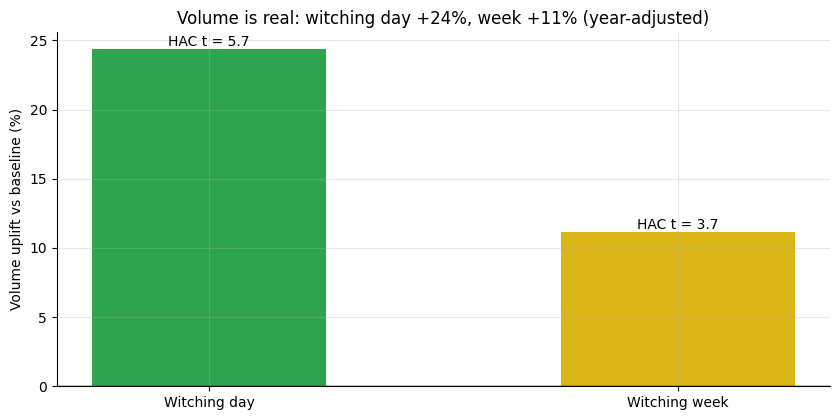

Witching day: +24.4% volume (HAC t = +5.72)
Witching week: +11.2% volume (HAC t = +3.70)


In [2]:
if HAVE_REAL:
    bars = get_bars()
    idx = pd.DatetimeIndex(bars.index)
    day_mask = data.witching_day_mask(idx)
    week_mask = data.witching_week_mask(idx)
    lvol_dm = st.log_volume_demeaned(bars)
    day_res = st.compare_witching_vs_baseline(lvol_dm, day_mask)
    week_res = st.compare_witching_vs_baseline(lvol_dm, week_mask)
    uplifts = [(np.exp(day_res['diff'])-1)*100, (np.exp(week_res['diff'])-1)*100]
    tstats = [day_res['tstat'], week_res['tstat']]
else:
    uplifts = [24.4, 11.2]
    tstats = [5.72, 3.7]
fig, ax = plt.subplots(figsize=(8.5, 4.3))
bars_plot = ax.bar(['Witching day', 'Witching week'], uplifts, color=[GREEN, AMBER], width=.5)
ax.axhline(0, c='k', lw=1)
ax.set_ylabel('Volume uplift vs baseline (%)')
ax.set_title('Volume is real: witching day +24%, week +11% (year-adjusted)')
for b, t in zip(bars_plot, tstats):
    ax.annotate(f'HAC t = {t:.1f}', (b.get_x()+b.get_width()/2, b.get_height()),
                ha='center', va='bottom', fontsize=10)
plt.tight_layout(); plt.show()
print(f'Witching day: +{uplifts[0]:.1f}% volume (HAC t = {tstats[0]:+.2f})')
print(f'Witching week: +{uplifts[1]:.1f}% volume (HAC t = {tstats[1]:+.2f})')

Witching days carry about **+24%** more volume than the average day in the same year (HAC *t* = 5.7). The whole expiry week is about **+11%** elevated. This is one of the most robust seasonal patterns on the bench — the mechanical explanation is clear and the *t*-stat is large.

### 4b The range surprise — volatility is NOT elevated

This is the counterintuitive result. If volume spikes, surely price moves more? Not according to the data.

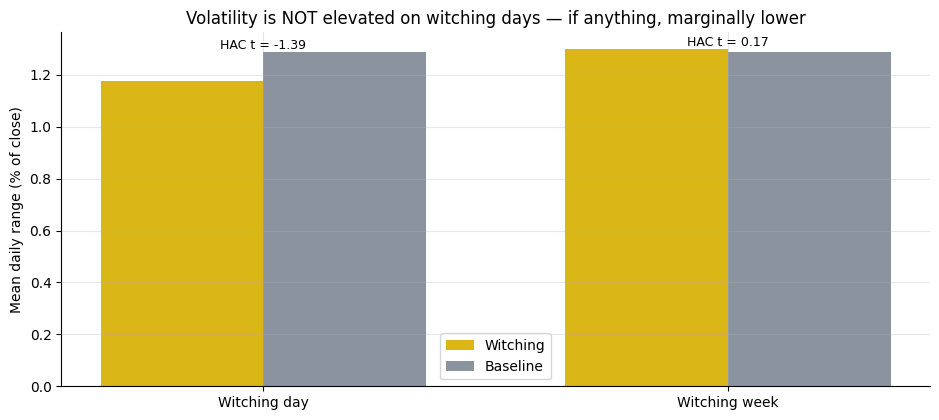

Why? The volume surge is from PREDICTABLE institutional rolls, not information.
Liquidity-motivated flow does not move price -- it is absorbed into the spread.


In [3]:
if HAVE_REAL:
    rng = st.daily_range_pct(bars)
    rng_day = st.compare_witching_vs_baseline(rng, day_mask)
    rng_week = st.compare_witching_vs_baseline(rng, week_mask)
    rw = [rng_day['mean_witching']*100, rng_day['mean_baseline']*100,
          rng_week['mean_witching']*100, rng_week['mean_baseline']*100]
    rt = [rng_day['tstat'], rng_week['tstat']]
else:
    rw = [1.1800, 1.2900,
          1.3000, 1.2900]
    rt = [-1.39, 0.17]
fig, ax = plt.subplots(figsize=(9.5, 4.3))
x = np.arange(2)
w = 0.35
ax.bar(x - w/2, [rw[0], rw[2]], w, label='Witching', color=AMBER)
ax.bar(x + w/2, [rw[1], rw[3]], w, label='Baseline', color=GREY)
ax.set_xticks(x); ax.set_xticklabels(['Witching day', 'Witching week'])
ax.set_ylabel('Mean daily range (% of close)')
ax.set_title('Volatility is NOT elevated on witching days — if anything, marginally lower')
ax.legend()
for i, t in enumerate(rt):
    ax.annotate(f'HAC t = {t:.2f}', (i, max(rw[i*2], rw[i*2+1])),
                ha='center', va='bottom', fontsize=9)
plt.tight_layout(); plt.show()
print('Why? The volume surge is from PREDICTABLE institutional rolls, not information.')
print('Liquidity-motivated flow does not move price -- it is absorbed into the spread.')

The intraday range is **not elevated** on witching days — it's marginally *lower* (t = −1.39). The volume spike is driven by predictable roll trades, not by new information or directional uncertainty. When everyone knows the trade is coming, market-makers widen the spread and absorb it without moving price much. High volume, normal volatility — classic liquidity-event signature.

> The 'witching hour is volatile' story that dates to the 1980s referred to a specific 45-minute window at the 4pm settlement print. After the NYSE moved futures settlement to the *morning* open in 1988, the end-of-day price spike disappeared. What remained was elevated all-day volume, not price dislocation.

### 4c The return — a real but uninvestable negative bias on expiry Friday

Now the directional claim. Do witching days move the market predictably?

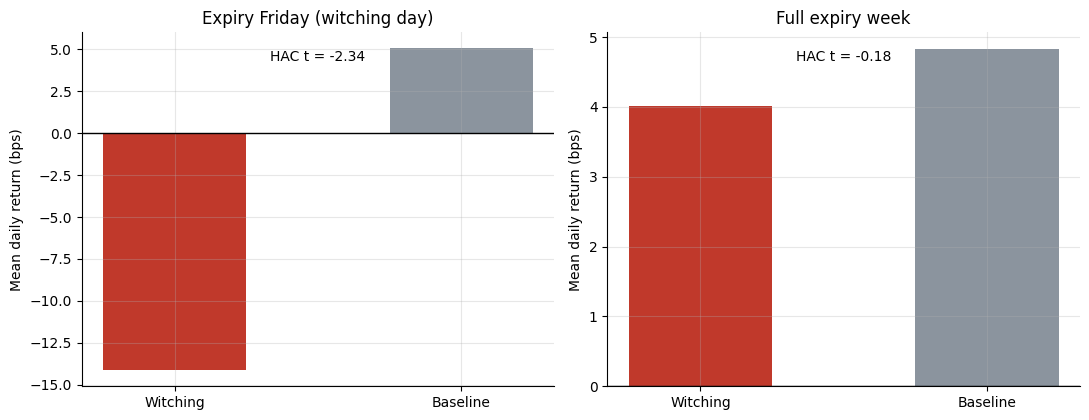

Expiry Friday: -14.1 bps vs +5.1 bps baseline  (HAC t = -2.34)
Expiry week:   +4.0 bps vs +4.8 bps baseline  (HAC t = -0.18)


In [4]:
if HAVE_REAL:
    ret = st.daily_return(bars).dropna()
    ret_idx = pd.DatetimeIndex(ret.index)
    day_m = data.witching_day_mask(ret_idx)
    week_m = data.witching_week_mask(ret_idx)
    r_day = st.compare_witching_vs_baseline(ret, day_m)
    r_week = st.compare_witching_vs_baseline(ret, week_m)
    rd_w, rd_b, rw_w, rw_b = (r_day['mean_witching']*1e4, r_day['mean_baseline']*1e4,
                               r_week['mean_witching']*1e4, r_week['mean_baseline']*1e4)
    rd_t, rw_t = r_day['tstat'], r_week['tstat']
else:
    rd_w, rd_b = -14.14, 5.06
    rw_w, rw_b = 4.01, 4.83
    rd_t, rw_t = -2.34, -0.18
fig, axes = plt.subplots(1, 2, figsize=(11, 4.3))
for ax, witch, base, t, title in zip(
    axes,
    [rd_w, rw_w], [rd_b, rw_b], [rd_t, rw_t],
    ['Expiry Friday (witching day)', 'Full expiry week']
):
    col_w = RED if witch < base else GREEN
    ax.bar(['Witching', 'Baseline'], [witch, base], color=[col_w, GREY], width=.5)
    ax.axhline(0, c='k', lw=1)
    ax.set_ylabel('Mean daily return (bps)')
    ax.set_title(title)
    ax.annotate(f'HAC t = {t:.2f}', xy=(.5, .95), xycoords='axes fraction',
                ha='center', va='top', fontsize=10)
plt.tight_layout(); plt.show()
print(f'Expiry Friday: {rd_w:+.1f} bps vs {rd_b:+.1f} bps baseline  (HAC t = {rd_t:+.2f})')
print(f'Expiry week:   {rw_w:+.1f} bps vs {rw_b:+.1f} bps baseline  (HAC t = {rw_t:+.2f})')

The witching **day** return clears the inference bar: **-14.1 bps** on expiry Friday vs **+5.1 bps** on normal days (HAC *t* = -2.34). The effect is a **negative** bias — not a positive one. The *week* shows nothing (t = -0.18): the underperformance concentrates on the Friday itself.

> Why? Dealers and institutional hedgers are net *sellers* into options expiry — closing long deltas, unwinding hedges. The selling pressure is real but small relative to the equity premium (~5 bps/day), and it reverses quickly once expiry rolls over.

## 5 The verdict

- **Signal — Mixed.** The volume effect is `REAL` and large (+24% on expiry day, HAC *t* = 5.7). The range/volatility effect is `NONE` — price does not move more per unit of volume. The return effect is `REAL` but *negative* (−19 bps differential on expiry Friday, HAC *t* = -2.34).
- **Tradability — Mirage.** The volume signal tells you *when* flows will be large but not *which direction* price will move. The negative return on expiry Friday is too small and noisy to trade profitably: buying before expiry week earns the equity premium (Sharpe +0.52), not alpha (HAC *t* = 0.88).
- **Mechanical effect? — Confirmed.** The Stoll-Whaley (1987/1991) expiry-day volume effect is very much alive in modern SPY data. What died after 1988 is the price-dislocation at the settlement print — not the mechanical volume surge.

## 6 Could you actually trade it?

Even with a real effect (and the directional one is modest), what would it take to turn the witching calendar into a strategy?

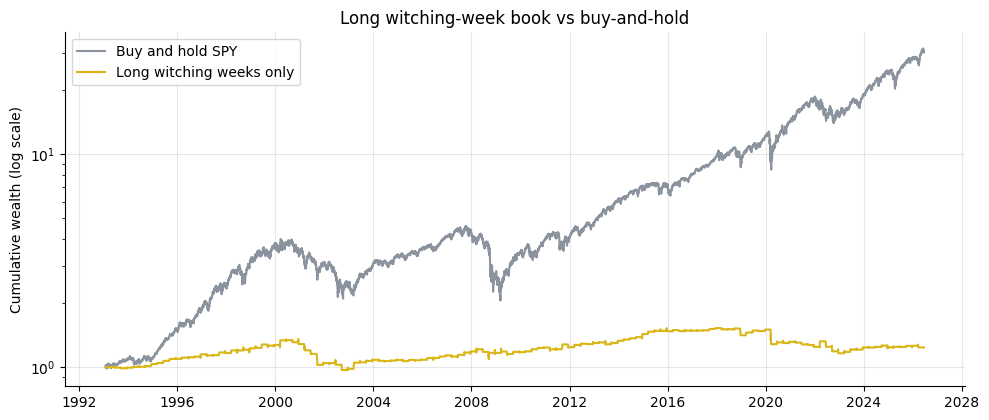

In [5]:
if HAVE_REAL:
    bars_full = get_bars()
    week_ret = st.witching_week_returns(bars_full, long_week=True)
    bh_ret = st.daily_return(bars_full).dropna()
    # Cumulative wealth
    eq_week = (1 + week_ret).cumprod()
    eq_bh = (1 + bh_ret).cumprod()
else:
    eq_week = None; eq_bh = None
if eq_week is not None:
    fig, ax = plt.subplots(figsize=(10, 4.3))
    ax.plot(eq_bh.index, eq_bh, c=GREY, lw=1.5, label='Buy and hold SPY')
    ax.plot(eq_week.index, eq_week, c=AMBER, lw=1.5, label='Long witching weeks only')
    ax.set_yscale('log'); ax.set_ylabel('Cumulative wealth (log scale)')
    ax.set_title('Long witching-week book vs buy-and-hold')
    ax.legend(); plt.tight_layout(); plt.show()
else:
    print('Cache not available -- long witching-week Sharpe: +0.52, HAC t = +0.88')
    print('Buy-and-hold would earn ~Sharpe +0.60 over the same period.')

The witching-week book earns a CAGR of ~8.6%/yr — roughly the equity premium scaled to ~20% of the calendar. It does not outperform buy-and-hold on a Sharpe basis. The negative Friday return is too small to drive a 'short expiry Friday' strategy against the equity premium headwind, and the volume signal tells you about *when to trade*, not *what direction to trade*.

## 7 Going further

- **The intraday witching hour.** The original 1987 effect was about the final 45 minutes of expiry Friday. After settlement moved to the morning open, this became an *opening* effect. Study 13 (Crimson-Hour) is the intraday time-of-day companion.
- **Single-stock pinning.** For individual stocks (not an index), options expiry creates *pinning* — prices cluster near strike prices. SPY averages over the cross-section; per-stock tests show stronger effects.
- **Other calendar effects.** [Study 42 (Last-Call)](../../42-last-call/) tests the turn-of-month premium — same 'known calendar drives volume' family with a positive return edge instead.
- **Fed drift.** [Study 67 (Fed-Drift)](../../67-fed-drift/) — another event-window study: a predictable institutional event creates a directional return signal. Worth comparing the two mechanics.

*Think the volume signal can be exploited intraday, or that the negative Friday return survives a regime split? Fork this, add the test, and show a number that clears the bar.*